# Assignment 4 - Part 4: Generative Adversarial Networks on MNIST

This notebook solves **Part 4 only** of ADS 2026 Assignment 4.

The objective is to build a lightweight Generative Adversarial Network (GAN) on the **MNIST** handwritten digit dataset. We implement a Generator, a Discriminator, a custom adversarial training loop, sample visualizations across epochs, and a discussion of mode collapse.


## 1. Imports and Configuration


In [1]:
import os
import time
from pathlib import Path

PROJECT_DIR = Path.cwd()
os.environ.setdefault("KERAS_HOME", str(PROJECT_DIR / ".keras"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers


RANDOM_SEED = 42
IMG_HEIGHT = 28
IMG_WIDTH = 28
IMG_CHANNELS = 1
BUFFER_SIZE = 20000
TRAIN_SUBSET_SIZE = 20000
BATCH_SIZE = 128
NOISE_DIM = 100
EPOCHS = 15
NUM_EXAMPLES_TO_GENERATE = 25
SAMPLE_EVERY = 1

OUTPUT_DIR = Path("outputs")
SAMPLE_DIR = OUTPUT_DIR / "gan_samples"
MODEL_DIR = Path("models")

for directory in [OUTPUT_DIR, SAMPLE_DIR, MODEL_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)
tf.keras.utils.set_random_seed(RANDOM_SEED)

plt.style.use("default")
plt.rcParams["figure.dpi"] = 110

print("TensorFlow version:", tf.__version__)
print("Keras cache directory:", os.environ["KERAS_HOME"])
print("Output directory:", OUTPUT_DIR.resolve())

TensorFlow version: 2.21.0
Keras cache directory: D:\SHARIF\TERM7\DATA\HW4\PART4\.keras
Output directory: D:\SHARIF\TERM7\DATA\HW4\PART4\outputs


## 2. Load MNIST Dataset



In [2]:
keras_cache_path = Path(os.environ["KERAS_HOME"]) / "datasets" / "mnist.npz"
print("Expected Keras MNIST cache:", keras_cache_path)
print("Cache file present before loading:", keras_cache_path.exists())

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)
print("x_test shape:", x_test.shape)
print("y_test shape:", y_test.shape)
print("Training image dtype:", x_train.dtype)
print("Training pixel range:", int(x_train.min()), "to", int(x_train.max()))

label_distribution = (
    pd.Series(y_train, name="digit")
    .value_counts()
    .sort_index()
    .rename_axis("digit")
    .to_frame("count")
)
label_distribution["fraction"] = label_distribution["count"] / label_distribution["count"].sum()
label_distribution

Expected Keras MNIST cache: D:\SHARIF\TERM7\DATA\HW4\PART4\.keras\datasets\mnist.npz
Cache file present before loading: True
x_train shape: (60000, 28, 28)
y_train shape: (60000,)
x_test shape: (10000, 28, 28)
y_test shape: (10000,)
Training image dtype: uint8
Training pixel range: 0 to 255


,count,fraction
digit,,
0,5923,0.098717
1,6742,0.112367
2,5958,0.099300
3,6131,0.102183
4,5842,0.097367
5,5421,0.090350
6,5918,0.098633
7,6265,0.104417
8,5851,0.097517


The labels are useful for checking the dataset, but they are **not** used by the Generator or Discriminator. In this GAN setup, the Discriminator only sees images and learns real versus fake scores.

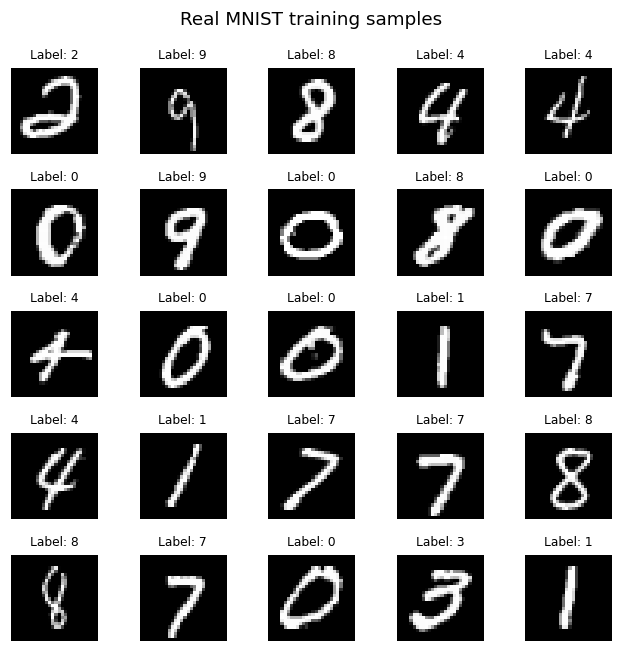

In [3]:
rng = np.random.default_rng(RANDOM_SEED)
real_sample_indices = rng.choice(len(x_train), size=25, replace=False)

fig, axes = plt.subplots(5, 5, figsize=(6, 6))
for ax, idx in zip(axes.ravel(), real_sample_indices):
    ax.imshow(x_train[idx], cmap="gray", vmin=0, vmax=255)
    ax.set_title(f"Label: {y_train[idx]}", fontsize=8)
    ax.axis("off")
fig.suptitle("Real MNIST training samples", fontsize=12)
fig.tight_layout()
plt.show()

## 3. Data Preprocessing

the Generator will use a `tanh` output layer, which naturally produces values in `[-1, 1]`.

float32 image tensors with a channel dimension, a lightweight training subset, and a batched `tf.data.Dataset` pipeline.

In [4]:
all_train_images = x_train.astype("float32")
all_train_images = (all_train_images - 127.5) / 127.5
all_train_images = np.expand_dims(all_train_images, axis=-1)

subset_rng = np.random.default_rng(RANDOM_SEED)
subset_size = min(TRAIN_SUBSET_SIZE, len(all_train_images))
subset_indices = subset_rng.choice(len(all_train_images), size=subset_size, replace=False)

train_images = all_train_images[subset_indices]
train_labels_for_eda = y_train[subset_indices]

train_dataset = (
    tf.data.Dataset.from_tensor_slices(train_images)
    .shuffle(BUFFER_SIZE, seed=RANDOM_SEED)
    .batch(BATCH_SIZE, drop_remainder=True)
    .prefetch(tf.data.AUTOTUNE)
)

first_batch = next(iter(train_dataset))

print("Subset image tensor shape:", train_images.shape)
print("Subset dtype:", train_images.dtype)
print("Subset pixel range:", float(train_images.min()), "to", float(train_images.max()))
print("One dataset batch shape:", first_batch.shape)
print("Subset label counts for EDA only:")
print(pd.Series(train_labels_for_eda).value_counts().sort_index().to_string())

assert train_images.dtype == np.float32
assert train_images.shape[1:] == (IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS)
assert first_batch.shape == (BATCH_SIZE, IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS)
assert np.isclose(train_images.min(), -1.0)
assert np.isclose(train_images.max(), 1.0)

Subset image tensor shape: (20000, 28, 28, 1)
Subset dtype: float32
Subset pixel range: -1.0 to 1.0
One dataset batch shape: (128, 28, 28, 1)
Subset label counts for EDA only:
0    2002
1    2206
2    1988
3    2074
4    1940
5    1780
6    2021
7    2052
8    1943
9    1994


Batching gives each update a stable mini-batch of images. Prefetching lets TensorFlow prepare the next batch while the current batch is being processed, which helps keep the training loop smooth even on CPU.

## 4. GAN Concept

A GAN contains two neural networks trained together:

- The **Generator** maps random noise vectors to fake digit images.
- The **Discriminator** maps images to real/fake logits.
- The Discriminator learns to distinguish real MNIST digits from generated digits.
- The Generator learns to fool the Discriminator into giving fake images high "real" scores.


## 5. Helper Visualization Functions

GANs are easiest to understand visually, especially on an image dataset like MNIST.


In [5]:
def denormalize_images(images):
    # Convert images from [-1, 1] to [0, 1] for plotting.
    images = np.asarray(images)
    images = (images + 1.0) / 2.0
    return np.clip(images, 0.0, 1.0)


def plot_image_grid(images, title, n=25, save_path=None, show=True):
    # Plot up to n grayscale images in a compact grid.
    images = denormalize_images(images)
    n = min(n, len(images))
    cols = int(np.ceil(np.sqrt(n)))
    rows = int(np.ceil(n / cols))

    fig, axes = plt.subplots(rows, cols, figsize=(1.35 * cols, 1.35 * rows))
    axes = np.asarray(axes).reshape(-1)

    for ax in axes:
        ax.axis("off")

    for idx in range(n):
        axes[idx].imshow(images[idx].squeeze(), cmap="gray", vmin=0, vmax=1)

    fig.suptitle(title, fontsize=12)
    fig.tight_layout()

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=150, bbox_inches="tight")

    if show:
        plt.show()
    else:
        plt.close(fig)

    return fig


def generate_and_plot_images(generator, noise, epoch, save=True, show=True):
    # Generate images from fixed noise, plot them, and optionally save the grid.
    predictions = generator(noise, training=False)
    save_path = SAMPLE_DIR / f"epoch_{epoch:03d}.png" if save else None
    plot_image_grid(
        predictions.numpy(),
        title=f"Generated MNIST samples - epoch {epoch}",
        n=NUM_EXAMPLES_TO_GENERATE,
        save_path=save_path,
        show=show,
    )
    return save_path


def plot_loss_curves(history_df):
    # Plot Generator and Discriminator losses across epochs.
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(history_df["epoch"], history_df["generator_loss"], marker="o", label="Generator")
    ax.plot(history_df["epoch"], history_df["discriminator_loss"], marker="o", label="Discriminator")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.set_title("GAN training losses")
    ax.grid(True, alpha=0.25)
    ax.legend()
    fig.tight_layout()
    plt.show()
    return fig


def show_generated_progress(sample_paths, max_cols=2):
    # Display saved sample-grid images from selected epochs.
    sample_paths = [Path(path) for path in sample_paths if Path(path).exists()]
    if not sample_paths:
        raise ValueError("No sample paths were found.")

    cols = min(max_cols, len(sample_paths))
    rows = int(np.ceil(len(sample_paths) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(5.0 * cols, 4.2 * rows))
    axes = np.asarray(axes).reshape(-1)

    for ax in axes:
        ax.axis("off")

    for ax, path in zip(axes, sample_paths):
        ax.imshow(plt.imread(path))
        ax.set_title(path.stem.replace("_", " ").title(), fontsize=10)

    fig.suptitle("Generated-sample progress with fixed noise", fontsize=12)
    fig.tight_layout()
    plt.show()
    return fig

The plotting helpers always convert generated images back to `[0, 1]` before display. This avoids misleading contrast when the model outputs are still in the training scale `[-1, 1]`.

## 6. Build the Generator



Model: "generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 6272)           │       627,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 6272)           │        25,088 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 7, 7, 64)       │       204,800 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 7, 7, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 14, 14, 32)     │        51,200 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 14, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 28, 28, 1)      │           800 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 909,472 (3.47 MB)

 Trainable params: 896,736 (3.42 MB)

 Non-trainable params: 12,736 (49.75 KB)

Dummy generated batch shape: (128, 28, 28, 1)
Dummy generated range: -0.1131926104426384 to 0.14343379437923431


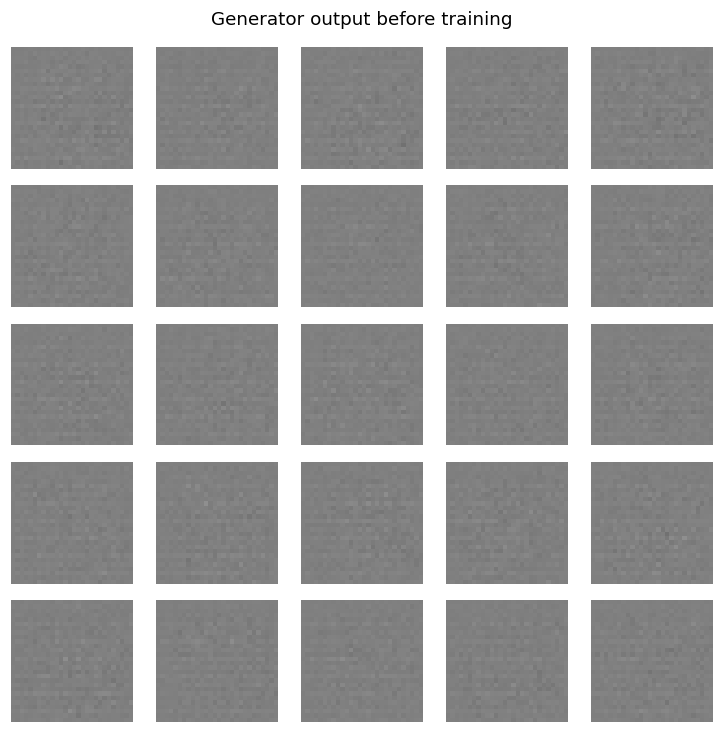

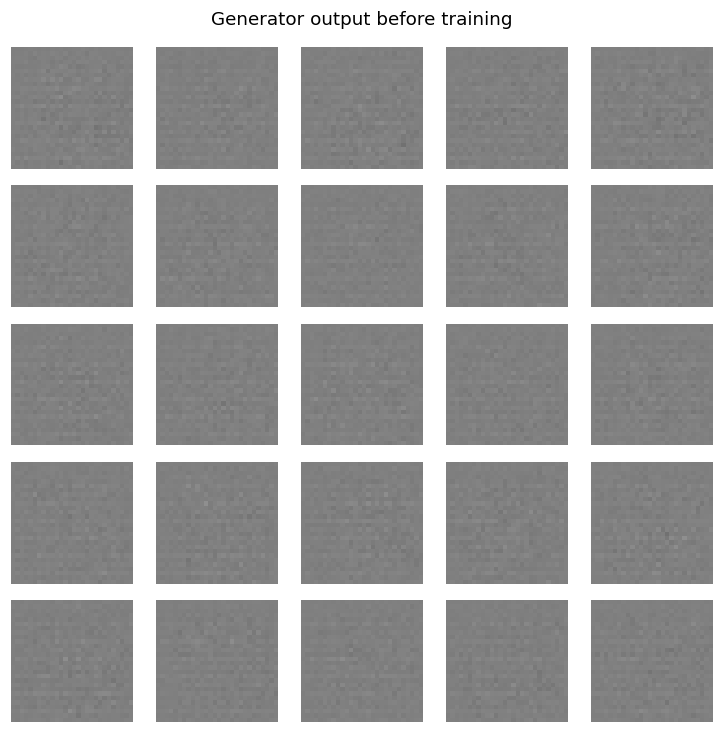

In [6]:
def build_generator(noise_dim=NOISE_DIM):
    model = keras.Sequential(
        [
            layers.Input(shape=(noise_dim,)),
            layers.Dense(7 * 7 * 128, use_bias=False),
            layers.BatchNormalization(),
            layers.LeakyReLU(),
            layers.Reshape((7, 7, 128)),
            layers.Conv2DTranspose(64, kernel_size=5, strides=1, padding="same", use_bias=False),
            layers.BatchNormalization(),
            layers.LeakyReLU(),
            layers.Conv2DTranspose(32, kernel_size=5, strides=2, padding="same", use_bias=False),
            layers.BatchNormalization(),
            layers.LeakyReLU(),
            layers.Conv2DTranspose(
                IMG_CHANNELS,
                kernel_size=5,
                strides=2,
                padding="same",
                use_bias=False,
                activation="tanh",
            ),
        ],
        name="generator",
    )
    return model


generator = build_generator(NOISE_DIM)
generator.summary()

dummy_noise = tf.random.normal([BATCH_SIZE, NOISE_DIM], seed=RANDOM_SEED)
dummy_generated_images = generator(dummy_noise, training=False)

print("Dummy generated batch shape:", dummy_generated_images.shape)
print(
    "Dummy generated range:",
    float(tf.reduce_min(dummy_generated_images)),
    "to",
    float(tf.reduce_max(dummy_generated_images)),
)

assert dummy_generated_images.shape == (BATCH_SIZE, IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS)
assert float(tf.reduce_min(dummy_generated_images)) >= -1.0
assert float(tf.reduce_max(dummy_generated_images)) <= 1.0

plot_image_grid(
    dummy_generated_images[:NUM_EXAMPLES_TO_GENERATE].numpy(),
    title="Generator output before training",
    n=NUM_EXAMPLES_TO_GENERATE,
)

The Generator starts from dense features, reshapes them to a small spatial map, and then uses transposed convolutions to upsample to MNIST size. The final `tanh` activation matches the `[-1, 1]` image normalization.

## 7. Build the Discriminator

Why this step matters: the Discriminator provides the learning signal that tells the Generator whether fake images look realistic.

What we gain: a small convolutional classifier that outputs one real/fake **logit** per image.

In [7]:
def build_discriminator():
    model = keras.Sequential(
        [
            layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS)),
            layers.Conv2D(64, kernel_size=5, strides=2, padding="same"),
            layers.LeakyReLU(),
            layers.Dropout(0.3),
            layers.Conv2D(128, kernel_size=5, strides=2, padding="same"),
            layers.LeakyReLU(),
            layers.Dropout(0.3),
            layers.Flatten(),
            layers.Dense(1),
        ],
        name="discriminator",
    )
    return model


discriminator = build_discriminator()
discriminator.summary()

real_output = discriminator(first_batch[:8], training=False)
fake_output = discriminator(dummy_generated_images[:8], training=False)

print("Discriminator output shape on real images:", real_output.shape)
print("Discriminator output shape on fake images:", fake_output.shape)
print("Example real logits:", real_output.numpy().reshape(-1)[:5])
print("Example fake logits:", fake_output.numpy().reshape(-1)[:5])

assert real_output.shape == (8, 1)
assert fake_output.shape == (8, 1)

Model: "discriminator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 14, 14, 64)     │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 7, 7, 128)      │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │         6,273 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 212,865 (831.50 KB)

 Trainable params: 212,865 (831.50 KB)

 Non-trainable params: 0 (0.00 B)

Discriminator output shape on real images: (8, 1)
Discriminator output shape on fake images: (8, 1)
Example real logits: [0.12392063 0.15483037 0.11924142 0.14581901 0.09311934]
Example fake logits: [0.00205777 0.00243108 0.00233132 0.00291064 0.00202127]


The final layer has no sigmoid activation. That means the model returns logits, and the loss function should be configured with `from_logits=True` for numerical stability.

## 8. Define Losses and Optimizers

Why this step matters: GAN training uses two related objectives, one for the Discriminator and one for the Generator.

What we gain: explicit loss functions that match the assignment's real/fake setup and a common Adam configuration for DCGAN-style training.

In [8]:
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=True)


def discriminator_loss(real_output, fake_output):
    real_loss = cross_entropy(tf.ones_like(real_output), real_output)
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
    total_disc_loss = real_loss + fake_loss
    return total_disc_loss


def generator_loss(fake_output):
    return cross_entropy(tf.ones_like(fake_output), fake_output)


generator_optimizer = tf.keras.optimizers.Adam(learning_rate=2e-4, beta_1=0.5)
discriminator_optimizer = tf.keras.optimizers.Adam(learning_rate=2e-4, beta_1=0.5)

loss_config = cross_entropy.get_config()
print("BinaryCrossentropy config:", loss_config)
assert loss_config["from_logits"] is True

BinaryCrossentropy config: {'name': 'binary_crossentropy', 'reduction': 'sum_over_batch_size', 'from_logits': True, 'label_smoothing': 0.0, 'axis': -1}


The Discriminator has two loss terms: real images should be classified as real, and generated images should be classified as fake. During the Generator update, fake images are intentionally labeled as real because the Generator is rewarded for fooling the Discriminator. Adam with `beta_1=0.5` is a common GAN choice because it can reduce unstable momentum behavior.

## 9. Implement and Verify One Training Step



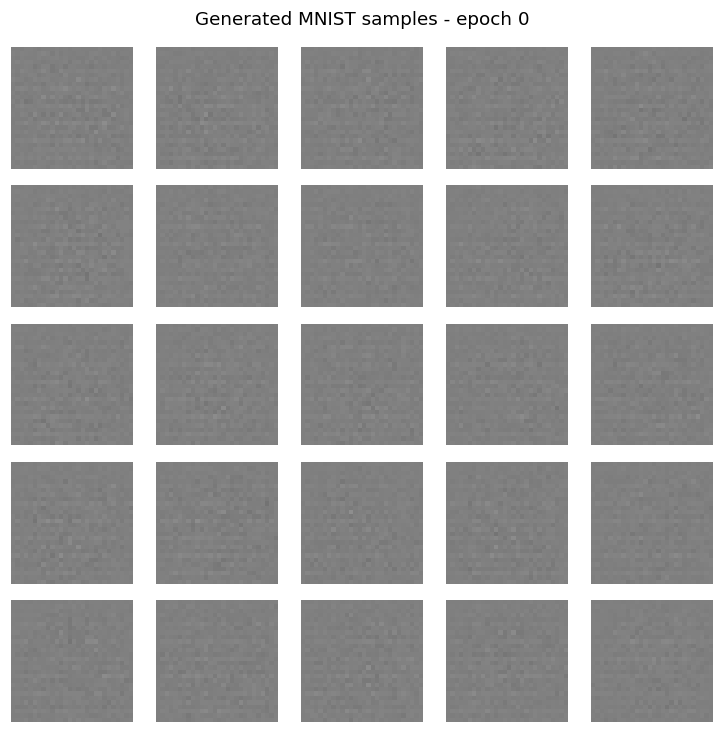

One-step generator loss: 0.6728633642196655
One-step discriminator loss: 1.3410604000091553
Initial samples saved to: outputs\gan_samples\epoch_000.png


In [9]:
@tf.function
def train_step(images):
    noise = tf.random.normal([BATCH_SIZE, NOISE_DIM])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        generated_images = generator(noise, training=True)

        real_output = discriminator(images, training=True)
        fake_output = discriminator(generated_images, training=True)

        gen_loss = generator_loss(fake_output)
        disc_loss = discriminator_loss(real_output, fake_output)

    gradients_of_generator = gen_tape.gradient(gen_loss, generator.trainable_variables)
    gradients_of_discriminator = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

    generator_optimizer.apply_gradients(
        zip(gradients_of_generator, generator.trainable_variables)
    )
    discriminator_optimizer.apply_gradients(
        zip(gradients_of_discriminator, discriminator.trainable_variables)
    )

    return gen_loss, disc_loss


fixed_seed_noise = tf.random.normal([NUM_EXAMPLES_TO_GENERATE, NOISE_DIM], seed=RANDOM_SEED)
initial_sample_path = generate_and_plot_images(generator, fixed_seed_noise, epoch=0, save=True, show=True)

test_gen_loss, test_disc_loss = train_step(first_batch)

print("One-step generator loss:", float(test_gen_loss))
print("One-step discriminator loss:", float(test_disc_loss))
print("Initial samples saved to:", initial_sample_path)

assert np.isfinite(float(test_gen_loss))
assert np.isfinite(float(test_disc_loss))
assert initial_sample_path.exists()

The step first creates fake images, asks the Discriminator to score both real and fake images, computes both losses, and applies gradients to both networks. The saved epoch 0 grid was generated before the sanity-check update, so it is a true untrained baseline.

## 10. Full Training Loop



In [10]:
def train_gan(dataset, epochs, seed_noise, initial_paths=None):
    history = []
    sample_paths = list(initial_paths or [])

    for epoch in range(1, epochs + 1):
        start_time = time.time()
        generator_losses = []
        discriminator_losses = []

        for image_batch in dataset:
            gen_loss_value, disc_loss_value = train_step(image_batch)
            generator_losses.append(float(gen_loss_value))
            discriminator_losses.append(float(disc_loss_value))

        epoch_gen_loss = float(np.mean(generator_losses))
        epoch_disc_loss = float(np.mean(discriminator_losses))

        if not np.isfinite(epoch_gen_loss) or not np.isfinite(epoch_disc_loss):
            raise ValueError(f"Non-finite loss detected at epoch {epoch}.")

        history.append(
            {
                "epoch": epoch,
                "generator_loss": epoch_gen_loss,
                "discriminator_loss": epoch_disc_loss,
            }
        )

        if epoch % SAMPLE_EVERY == 0 or epoch == epochs:
            sample_path = generate_and_plot_images(
                generator,
                seed_noise,
                epoch=epoch,
                save=True,
                show=False,
            )
            sample_paths.append(sample_path)

        elapsed = time.time() - start_time
        print(
            f"Epoch {epoch:02d}/{epochs} | "
            f"generator_loss={epoch_gen_loss:.4f} | "
            f"discriminator_loss={epoch_disc_loss:.4f} | "
            f"{elapsed:.1f}s"
        )

    history_df = pd.DataFrame(history)
    return history_df, sample_paths


history_df, sample_paths = train_gan(
    train_dataset,
    epochs=EPOCHS,
    seed_noise=fixed_seed_noise,
    initial_paths=[initial_sample_path],
)

history_path = OUTPUT_DIR / "gan_training_history.csv"
history_df.to_csv(history_path, index=False)

print("Training history saved to:", history_path)
history_df.tail()

Epoch 01/15 | generator_loss=0.8495 | discriminator_loss=0.9663 | 10.6s


Epoch 02/15 | generator_loss=0.9032 | discriminator_loss=1.1682 | 10.6s


Epoch 03/15 | generator_loss=0.8387 | discriminator_loss=1.2597 | 10.6s


Epoch 04/15 | generator_loss=0.8191 | discriminator_loss=1.2827 | 11.0s


Epoch 05/15 | generator_loss=0.8191 | discriminator_loss=1.2872 | 10.7s


...

Epoch 12/15 | generator_loss=0.8622 | discriminator_loss=1.2541 | 11.0s


Epoch 13/15 | generator_loss=0.8439 | discriminator_loss=1.2858 | 11.3s


Epoch 14/15 | generator_loss=0.8259 | discriminator_loss=1.2982 | 11.1s


Epoch 15/15 | generator_loss=0.8290 | discriminator_loss=1.2948 | 11.1s
Training history saved to: outputs\gan_training_history.csv


,epoch,generator_loss,discriminator_loss
10,11,0.886864,1.225439
11,12,0.862155,1.254149
12,13,0.843904,1.285785
13,14,0.825859,1.298207
14,15,0.828968,1.294754


The fixed noise vectors make the saved grids comparable across epochs. Changes in the images come from the Generator's learned weights, not from changing random inputs.

## 11. Loss Curves

GAN losses do not behave like ordinary supervised validation curves, but they still help diagnose instability, divergence, or obvious training failure.



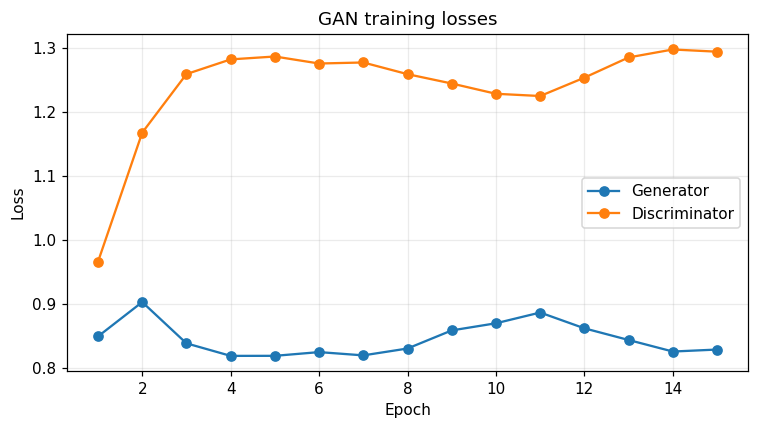

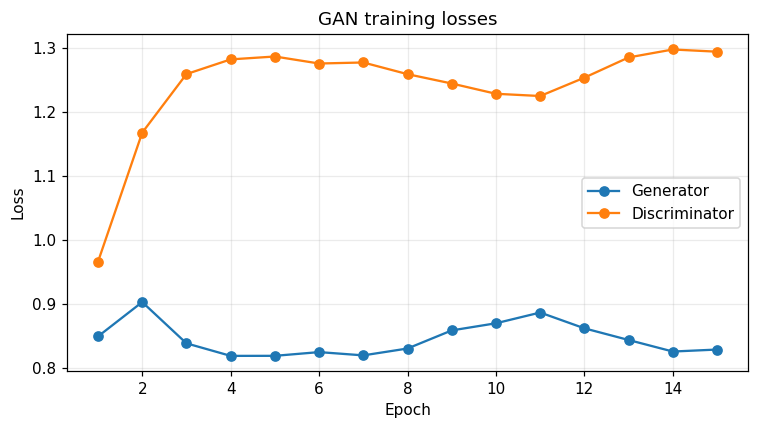

In [11]:
plot_loss_curves(history_df)

Losses should be interpreted carefully. A lower Generator loss can mean the Generator is fooling the Discriminator, but it can also mean the Discriminator is weak. The image grids are therefore just as important as the curves.

## 12. Generated-Sample Progress

the main product of this GAN is the generated image distribution.


Selected epochs: [0, 1, 7, 15]
Selected sample files:
- outputs\gan_samples\epoch_000.png exists: True
- outputs\gan_samples\epoch_001.png exists: True
- outputs\gan_samples\epoch_007.png exists: True
- outputs\gan_samples\epoch_015.png exists: True


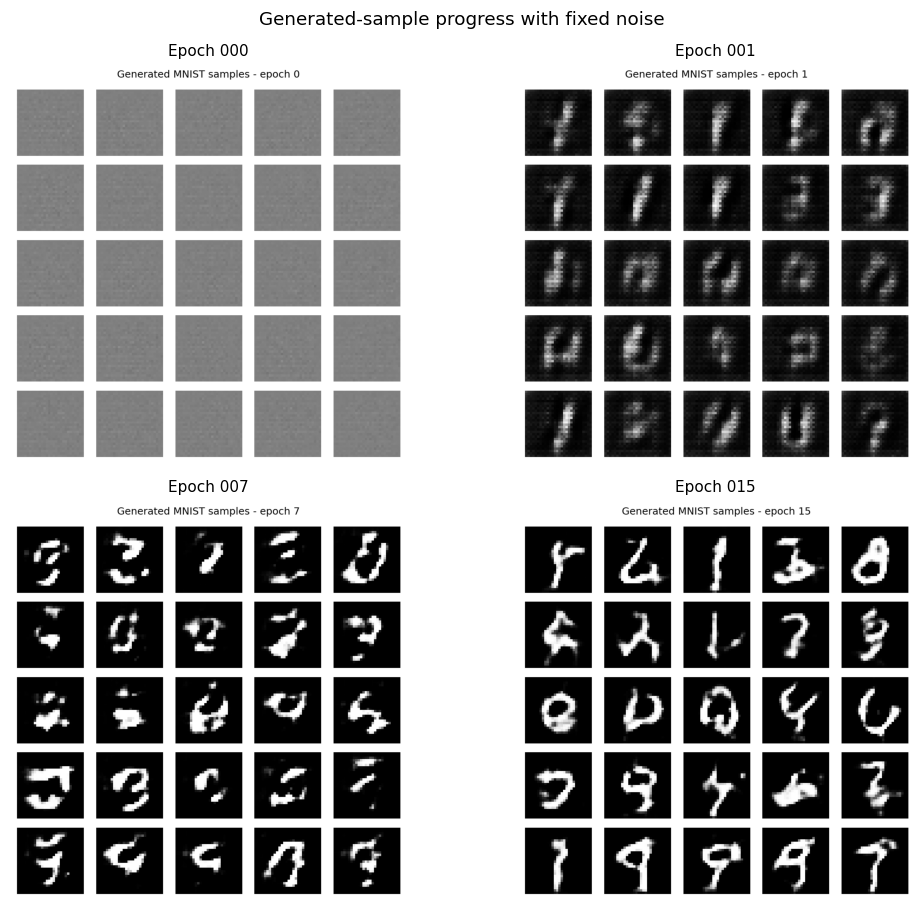

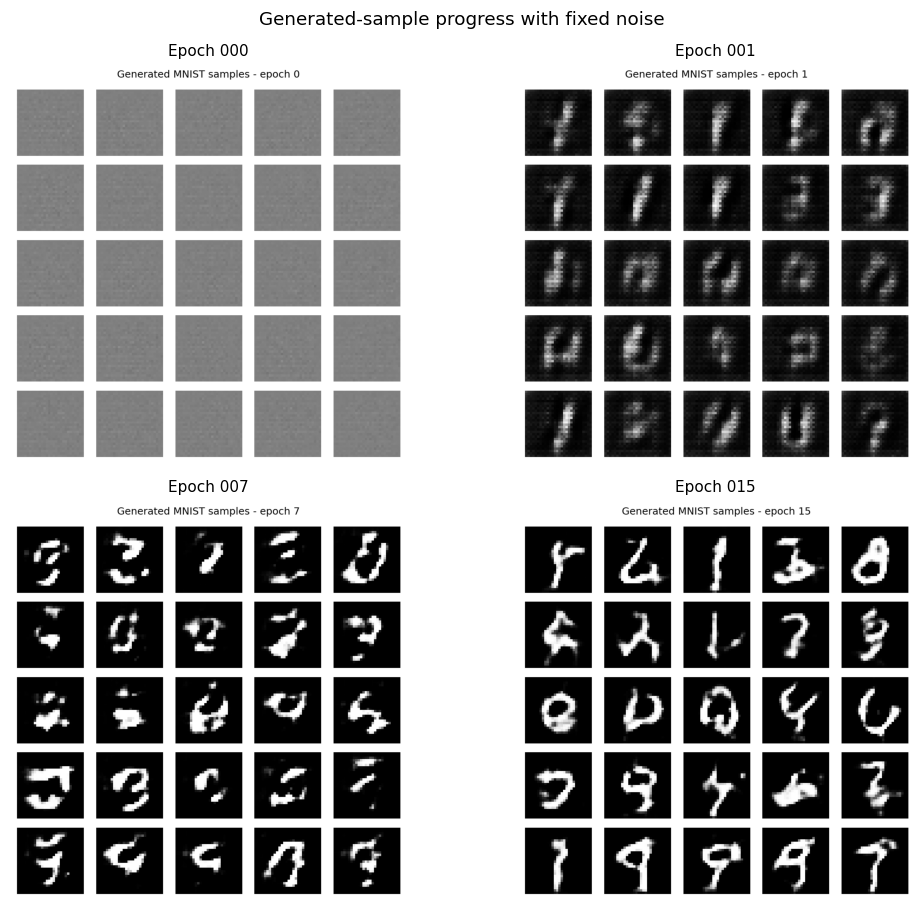

In [12]:
selected_epochs = sorted({0, 1, max(1, EPOCHS // 2), EPOCHS})
selected_sample_paths = [SAMPLE_DIR / f"epoch_{epoch:03d}.png" for epoch in selected_epochs]

print("Selected epochs:", selected_epochs)
print("Selected sample files:")
for path in selected_sample_paths:
    print("-", path, "exists:", path.exists())

show_generated_progress(selected_sample_paths)

The comparison should show a movement from unstructured gray/noisy patterns toward digit-like strokes. Because this is a deliberately lightweight CPU run, the final images may still be blurry or imperfect.

## 13. Optional Simple Quality Checks

formal GAN metrics such as FID or Inception Score are unnecessary and heavy for this homework.


Generated quality batch shape: (100, 28, 28, 1)
Generated quality batch range: -1.0 to 1.0
Generated quality batch mean: -0.7296696901321411
Generated quality batch std: 0.6224304437637329


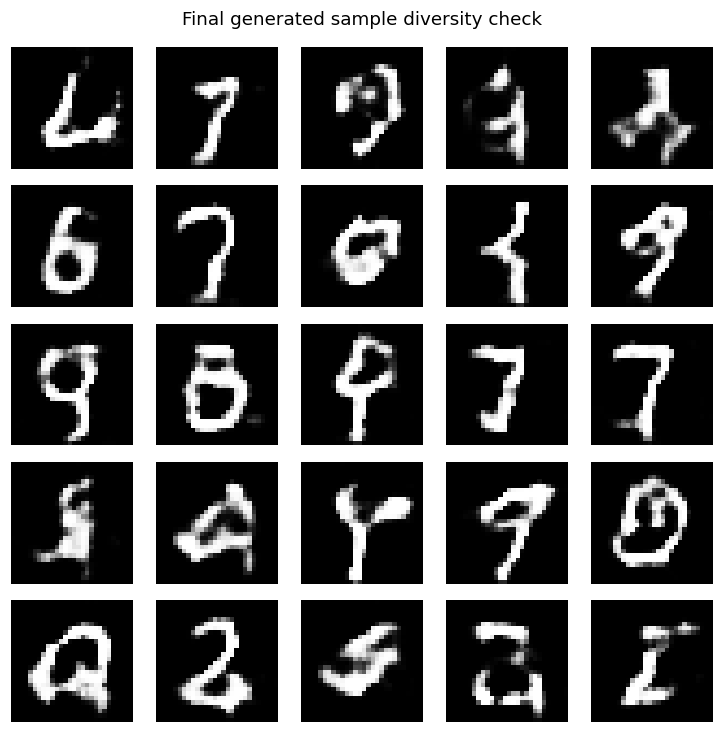

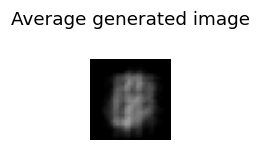

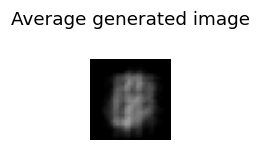

In [13]:
quality_noise = tf.random.normal([100, NOISE_DIM], seed=RANDOM_SEED + 1)
quality_generated = generator(quality_noise, training=False).numpy()

print("Generated quality batch shape:", quality_generated.shape)
print("Generated quality batch range:", float(quality_generated.min()), "to", float(quality_generated.max()))
print("Generated quality batch mean:", float(quality_generated.mean()))
print("Generated quality batch std:", float(quality_generated.std()))

assert quality_generated.shape == (100, IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS)
assert quality_generated.min() >= -1.0
assert quality_generated.max() <= 1.0

plot_image_grid(quality_generated[:25], title="Final generated sample diversity check", n=25)

average_generated_image = np.mean(quality_generated, axis=0, keepdims=True)
plot_image_grid(average_generated_image, title="Average generated image", n=1)

Qualitative evaluation is acceptable here because the assignment focuses on understanding the GAN mechanism, not state-of-the-art generation. FID and Inception Score are common GAN metrics, but they would add unnecessary complexity for this small MNIST notebook.

## 14. Discussion: Mode Collapse

**Mode collapse** happens when the Generator produces only a limited set of outputs instead of covering the full data distribution. On MNIST, a collapsed Generator might repeatedly produce one digit type, one stroke style, or a small set of nearly identical samples even though the true dataset contains many digit classes and writing styles.

GANs can suffer from mode collapse because training is a minimax adversarial game. If the Generator discovers a small region of image space that repeatedly fools the current Discriminator, the gradients may keep pulling many different noise inputs toward that same high-reward region. The objectives are non-convex, both networks are changing at the same time, and the Discriminator's feedback can become sharp or uneven. As a result, the Generator may learn "what works right now" rather than learning a broad mapping from noise to diverse images.

There is no formal guarantee that mode collapse will occur in every GAN run. It is a possible failure mode, not a mathematical necessity. Whether it appears depends on the architecture, optimizer, learning rates, batch size, loss function, random seed, data distribution, and training dynamics. Better gradients from the Discriminator, enough Generator capacity, suitable regularization, and GAN variants such as WGAN or WGAN-GP can reduce the risk.

For this MNIST experiment, we should inspect the generated grids carefully. If the final samples show several digit-like shapes and stroke styles, that is evidence against severe collapse in this run. If many fixed-noise inputs produce nearly identical digits, that would suggest partial collapse. Because this is a small CPU-friendly experiment, we should avoid overclaiming from a short training run.

## 15. Final Analysis

The Generator learned to transform random noise into images that increasingly resemble MNIST-style digit strokes. The epoch 0 grid is almost uniform gray texture because the untrained Generator is only producing small random variations around the middle of the `tanh` range. By the middle of training, the samples have high-contrast white strokes on black backgrounds, but many are still broken fragments. By epoch 15, several samples resemble rough MNIST-like loops and strokes, including shapes similar to `0`, `2`, `6`, `7`, and `9`, although they remain blurry and distorted.

The Discriminator learned a real/fake scoring function over `28x28x1` images. Its loss competes with the Generator loss, so neither curve should be interpreted like a normal validation metric. In this run, the Generator loss stayed around the high `0.7` to low `0.9` range and the Discriminator loss stayed around roughly `1.0` to `1.3`, which suggests neither network completely overpowered the other during the short run.

There is no strong visual sign of severe mode collapse because the final fixed-noise grid contains multiple stroke patterns and several digit-like shapes rather than one identical image repeated everywhere. However, diversity is still limited: many outputs lean toward loop-like or hook-like shapes, and the model does not cover all ten digit classes clearly. This is better described as a short-run quality limitation and possible partial diversity weakness, not proof of full collapse.
